### Cloud vs On-Premise: A Data-Driven Analysis of Infrastructure Efficiency, Cost, and Reliability
## By Tyrif Thorney (tthorney2023@fau.edu), Pedro Brizuela Kury (pbrizuelakur2024@fau.edu), Joseph Keller (kellerj2023@fau.edu)

### Abstract.
This project examines the trade-offs between cloud services and on-premises infrastructure, employing a data-driven approach to understand the differences in cost, reliability, and performance. The analysis integrates public outage logs, aggregated reports, and synthetic datasets and applies hypothesis testing, Random Forest regression, and scenario modeling to uncover patterns and insights related to comparative cost and downtime. Results indicate that while cloud infrastructure lowers average operational costs, it introduces exposure to systemic, high-impact outages, contributing to a clearer understanding of quantitative factors in infrastructure decisions. This research demonstrates how data science methods can support evidence-based reasoning in IT infrastructure management.

#### Keywords: Cloud Computing, On-Premise Infrastructure, Cost-Benefit Analysis, System Reliability, IT Infrastructure, Data-Driven Decision Making

Dataset being used:
- Google Cloud Public Incident Feed: https://status.cloud.google.com/incidents.json (Public Data Collection)
- Synthetic datasets generated via Monte Carlo simulation for AWS, Azure, Cloudflare, and On-Premise scenarios.
- Curated dataset combining real and synthetic data for comprehensive analysis.
### --- Google Cloud JSON feed snippet (Public Data Collection) ---
```ts
{
  "id": "8cY8jdUpEGGbsSMSQk7J",
  "begin": "2024-03-21 12:14:00+00:00",
  "end":   "2024-03-21 15:08:00+00:00",
  "year": 2024,
  "duration_hours": 2.9,
  "severity": "medium",
  "severity_score": 2,
  "incident_type": "disruption",
  "affected_product_count": 12,
  "region_scope": 3,
  "is_global": false
}
```
### --- Final curated dataset structure snippet ---
```ts
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   company_id                         100 non-null    int64  
 1   company_name                       100 non-null    object
 2   infrastructure_type                100 non-null    object
 3   provider                           100 non-null    object
 4   estimated_uptime_pct               100 non-null    float64
 5   annual_downtime_hours              100 non-null    float64
 6   incident_frequency_per_year        100 non-null    int64  
 7   mttr_hours                         100 non-null    float64
 8   monthly_cost_usd                   100 non-null    float64
 9   performance_index                  100 non-null    int64  
 10  security_incidents_per_year        100 non-null    int64  
 11  scalability_score                  100 non-null    int64  
 12  annual_revenue_usd                 100 non-null    float64
 13  revenue_loss_per_hour_usd          100 non-null    float64
 14  annual_downtime_business_loss_usd  100 non-null    float64

```

In [15]:
#Import required libraries
%pip install requests pandas numpy seaborn
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import random
import seaborn as sn

file_id = "1kgMgToIct2yJYlQKF74GUaoIjFryBQjt"
download_url = f"https://drive.google.com/uc?id={file_id}&export=download"

try:
    df_simulated_data = pd.read_json(download_url)
    is_simulated_data_loaded = True
except Exception as e:
    print("Error loading simulated data:", e)
    df_simulated_data = None
    is_simulated_data_loaded = False

print("Simulated data loaded:", is_simulated_data_loaded)

Simulated data loaded: True


#### --- Google Cloud JSON feed snippet (Public Data Collection) ---

In [16]:
# --------------------------------------------------------
# 1. Download & Parse GCP Public Incident Feed
# --------------------------------------------------------
if not is_simulated_data_loaded:
    url = "https://status.cloud.google.com/incidents.json"
    resp = requests.get(url)

    if resp.status_code != 200:
        raise Exception(f"Failed to fetch GCP incidents: {resp.status_code}")
    data = resp.json()

    # Normalize into a flat DataFrame
    df_gcp = pd.json_normalize(data)

    #export raw data for reference
    df_gcp.to_json("raw_gcp_incident_data.json", orient="records", lines=False)

    # --------------------------------------------------------
    # 2. Clean Timestamps
    # --------------------------------------------------------
    df_gcp["begin"] = pd.to_datetime(df_gcp["begin"], utc=True, errors="coerce")
    df_gcp["end"]   = pd.to_datetime(df_gcp["end"], utc=True, errors="coerce")

    # Drop rows where timestamps failed to parse
    df_gcp = df_gcp.dropna(subset=["begin", "end"]).reset_index(drop=True)

    # --------------------------------------------------------
    # 3. Compute Duration per Incident
    # --------------------------------------------------------
    df_gcp["duration_hours"] = (
        df_gcp["end"] - df_gcp["begin"]
    ).dt.total_seconds() / 3600
    # --------------------------------------------------------
    # 4. Compute Dataset Timespan (Across All Years)
    # --------------------------------------------------------
    start_year = df_gcp["begin"].min()
    end_year   = df_gcp["end"].max()

    n_years = (end_year - start_year).days / 365.25

    # Sanity check
    print("Dataset covers years:", sorted(df_gcp['begin'].dt.year.unique()))
    print(f"Timespan in years: {n_years:.3f}")

    # --------------------------------------------------------
    # 5. Compute Provider-Wide Reliability Metrics
    # --------------------------------------------------------
    incident_frequency = len(df_gcp)
    annual_downtime_hours = df_gcp["duration_hours"].sum() / n_years   # normalize to per-year
    mttr = df_gcp["duration_hours"].mean()

    # Poisson rate λ (incidents per year)
    lambda_global = incident_frequency / n_years

    # Uptime percentage
    uptime_pct = 100 * (1 - annual_downtime_hours / (365 * 24))

    # --------------------------------------------------------
    # 6. Print Clean Summary
    # --------------------------------------------------------
    print("---------------------------------------------------")
    print("GOOGLE CLOUD PUBLIC OUTAGE SUMMARY")
    print("---------------------------------------------------")
    print(f"Total incidents observed:     {incident_frequency}")
    print(f"Timespan (years):             {n_years:.3f}")
    print(f"Incident frequency per year:  {lambda_global:.2f} (λ)")
    print(f"Annual downtime (hours):      {annual_downtime_hours:.2f}")
    print(f"Mean time to recovery (hours):{mttr:.2f}")
    print(f"Estimated uptime percent:     {uptime_pct:.4f}%")
    print("---------------------------------------------------")

    # Keep df_gcp for downstream Monte Carlo modeling
    df_gcp_cleaned = df_gcp.copy()
else:
    print("Using simulated data for downstream analysis.")

Using simulated data for downstream analysis.


### Curate Public Data Source
A — Build the curated dataset (severity → numbers, region counts, etc.)

B — Build the Monte Carlo simulator (synthetic AWS, Azure, Cloudflare, On-Prem)

C — Build the final 100-company dataset

In [17]:
# ----------------------------
# A — CURATE GCP INCIDENT DATA
# ----------------------------
if not is_simulated_data_loaded:
    # We're expecting df_gcp from the previous cell
    df = df_gcp_cleaned.copy()

    # --------------------------------------------------------
    # 1. Normalize Severity into Numeric Levels
    # --------------------------------------------------------
    severity_map = {
        "low": 1,
        "medium": 2,
        "high": 3
    }
    df["severity_score"] = df["severity"].map(severity_map).fillna(0)

    # --------------------------------------------------------
    # 2. Normalize Impact Type (Outage vs Disruption vs Info)
    # --------------------------------------------------------
    def normalize_impact(v):
        if isinstance(v, str):
            if "OUTAGE" in v.upper():
                return "outage"
            elif "DISRUPTION" in v.upper():
                return "disruption"
            else:
                return "informational"
        return "unknown"

    df["incident_type"] = df["status_impact"].apply(normalize_impact)

    # --------------------------------------------------------
    # 3. Count affected products (services)
    # --------------------------------------------------------
    def count_products(x):
        try:
            return len(x)
        except:
            return 0

    df["affected_product_count"] = df["affected_products"].apply(count_products)

    # --------------------------------------------------------
    # 4. Count affected regions
    # --------------------------------------------------------
    def count_regions(loc_list):
        try:
            return len(loc_list)
        except:
            return 0

    df["region_scope"] = df["previously_affected_locations"].apply(count_regions)

    # --------------------------------------------------------
    # 5. Global outage flag
    # --------------------------------------------------------
    def detect_global(loc_list):
        if not isinstance(loc_list, list):
            return False
        for loc in loc_list:
            title = loc.get("title", "").lower()
            if "global" in title:
                return True
        return False

    df["is_global"] = df["previously_affected_locations"].apply(detect_global)

    # --------------------------------------------------------
    # 6. Incident year (for grouping)
    # --------------------------------------------------------
    df["year"] = df["begin"].dt.year

    # --------------------------------------------------------
    # 7. Select curated fields
    # --------------------------------------------------------
    curated_cols = [
        "id",
        "begin",
        "end",
        "year",
        "duration_hours",
        "severity",
        "severity_score",
        "incident_type",
        "affected_product_count",
        "region_scope",
        "is_global"
    ]

    df_gcp_curated = df[curated_cols].copy()

    print("Curated GCP Incident Dataset:")
    # print(df_gcp_curated.head())
    print(f"\nTotal curated incidents: {len(df_gcp_curated)}")
else:
    print("Using simulated data for downstream analysis.")

Using simulated data for downstream analysis.


## --------------------------------------------------------
#### Monte Carlo Simulator & Synthetic Company Dataset
## --------------------------------------------------------

In [18]:
# ============================
# B — MONTE CARLO SIMULATOR (HIERARCHICAL MODEL)
# Providers = global processes
# Companies = local entities
# ============================

if not is_simulated_data_loaded:
    # ----------------------------
    # 1. Base GCP statistics
    # ----------------------------
    base = df_gcp_curated.copy()

    start_time = base["begin"].min()
    end_time   = base["end"].max()
    n_years    = (end_time - start_time).days / 365.25

    lambda_gcp = len(base) / n_years
    duration_samples = base["duration_hours"].values

    print(f"Base λ (GCP incidents/year): {lambda_gcp:.2f}")
    print(f"Real GCP incidents used:     {len(duration_samples)}")
    print(f"Dataset timespan (years):    {n_years:.3f}")

    # ----------------------------
    # 2. Provider-level models (ONLY ONE EACH)
    # ----------------------------
    providers = {
        "GCP": {
            "lambda": lambda_gcp,
            "duration_scale": 1.0
        },
        "AWS": {
            "lambda": 0.9 * lambda_gcp,
            "duration_scale": 0.9
        },
        "Azure": {
            "lambda": 1.1 * lambda_gcp,
            "duration_scale": 1.0
        },
        "Cloudflare": {
            "lambda": 1.2 * lambda_gcp,
            "duration_scale": 1.1
        }
    }

    # ----------------------------
    # 3. Generate provider incident calendars (1 year)
    # ----------------------------
    provider_incidents = {}

    for provider, cfg in providers.items():
        n_events = np.random.poisson(cfg["lambda"])
        durations = np.random.choice(duration_samples, size=n_events, replace=True)
        durations = durations * cfg["duration_scale"]

        provider_incidents[provider] = durations

    print("\nProvider incident counts:")
    for k, v in provider_incidents.items():
        print(k, len(v))

    # ----------------------------
    # 4. Generate 100 companies
    # ----------------------------
    on_prem_companies = [
    "Netflix",
    "Spotify",
    "Airbnb",
    "Uber",
    "Lyft",
    "Pinterest",
    "Snap Inc. (Snapchat)",
    "Twitch",
    "Twitter (X Corp)",
    "Slack",
    "Zoom Video Communications",
    "Salesforce",
    "Target",
    "Walmart",
    "Adobe",
    "NVIDIA",
    "Epic Games (Fortnite)",
    "Capital One",
    "HSBC",
    "Goldman Sachs",
    "PayPal",
    "T-Mobile",
    "Verizon",
    "BMW",
    "General Motors (GM)",
    "Cisco",
    "NASA",
    "U.S. Department of Defense",
    "Johnson & Johnson",
    "Pfizer",
    "HCA Healthcare",
    "The Walt Disney Company",
    "Comcast",
    "Kellogg's",
    "Unilever",
    "McDonald's",
    "L'Oréal Groupe",
    "Samsung Electronics",
    "The New York Times",
    "GitLab",
    "Deloitte",
    "Palo Alto Networks",
    "Vodafone",
    "Deutsche Telekom",
    "Airbus",
    "Box",
    "Dropbox",
    "Redfin",
    "Coursera",
    "Duolingo"
    ]
    cloud_companies = [
    "Alibaba Cloud",
    "IBM Cloud",
    "Oracle Cloud Infrastructure (OCI)",
    "Tencent Cloud",
    "Huawei Cloud",
    "DigitalOcean",
    "OVHcloud",
    "Rackspace Technology",
    "Linode (Akamai)",
    "Kamatera",
    "Vultr",
    "Hetzner",
    "Salesforce Cloud (SaaS focus)",
    "SAP Cloud Platform",
    "VMware Cloud",
    "Cisco Cloud",
    "Red Hat Hybrid Cloud",
    "CloudSigma",
    "Scaleway",
    "UpCloud",
    "Exoscale",
    "DreamHost",
    "Hostinger",
    "Liquid Web",
    "SiteGround",
    "Bluehost (Cloud Hosting)",
    "HostGator (Cloud Hosting)",
    "InMotion Hosting",
    "A2 Hosting",
    "Namecheap (Cloud Hosting)",
    "IONOS by 1&1",
    "Serverspace.us",
    "PhoenixNAP",
    "Civo",
    "Kingsoft Cloud",
    "T-Systems (Deutsche Telekom)",
    "NTT Communications",
    "Fujitsu Cloud",
    "Hitachi Cloud",
    "Cloudways (Managed Cloud Platform)",
    "Wasabi Technologies (Cloud Storage)",
    "Backblaze (B2 Cloud Storage)",
    "Zetacloud",
    "Cosmic JS",
    "Atlantic.Net",
    "Deno Deploy",
    "CoreWeave",
    "Leaseweb",
    "Lambda",
    "Render"
    ]
    company_id = 1

    # ---- CLOUD COMPANIES ----
    cloud_company_configs = []
    for i in range(len(cloud_companies)):
        provider = random.choice(list(providers.keys()))

        cloud_company_configs.append({
            "company_id": company_id,
            "company_name": cloud_companies[i],
            "infra_type": "cloud",
            "provider": provider,
            "p_affect": np.random.uniform(0.05, 0.25),
            "mttr_scale": np.random.uniform(0.7, 1.3)
        })
        company_id += 1

    # ---- ON-PREM COMPANIES ----
    on_prem_company_configs = []
    for i in range(len(on_prem_companies)):
        on_prem_company_configs.append({
            "company_id": company_id,
            "company_name": on_prem_companies[i],
            "infra_type": "on_prem",
            "provider": "OnPrem",
            "lambda_local": np.random.uniform(4, 10),
            "mttr_scale": np.random.uniform(1.2, 2.0)
        })
        company_id += 1

    # ----------------------------
    synthetic_records = []

    for c in on_prem_company_configs + cloud_company_configs:

        annual_downtime = 0
        incident_count = 0

        # ---- CLOUD COMPANIES INHERIT PROVIDER INCIDENTS ----
        if c["infra_type"] == "cloud":
            incidents = provider_incidents[c["provider"]]

            for d in incidents:
                if np.random.rand() < c["p_affect"]:
                    annual_downtime += d * c["mttr_scale"]
                    incident_count += 1

            monthly_cost = np.random.uniform(4000, 40000)
            scalability_score = np.random.uniform(80, 100)
            performance_index = np.random.uniform(80, 98)
            security_incidents = np.random.poisson(0.5)

        # ---- ON-PREM COMPANIES GENERATE OWN FAILURES ----
        else:
            n_local = np.random.poisson(c["lambda_local"])
            local_durations = np.random.choice(duration_samples, size=n_local, replace=True)

            annual_downtime = sum(local_durations * c["mttr_scale"])
            incident_count = n_local

            monthly_cost = np.random.uniform(6000, 120000)
            scalability_score = np.random.uniform(40, 70)
            performance_index = np.random.uniform(65, 88)
            security_incidents = np.random.poisson(2.0)

        uptime_pct = max(0, 100 * (1 - annual_downtime / (365 * 24)))

        synthetic_records.append({
            "company_id": c["company_id"],
            "company_name": c["company_name"],
            "infrastructure_type": c["infra_type"],
            "provider": c["provider"],
            "estimated_uptime_pct": round(uptime_pct, 3),
            "annual_downtime_hours": round(float(annual_downtime), 2),
            "incident_frequency_per_year": int(incident_count),
            "mttr_hours": round(float(annual_downtime / incident_count), 2) if incident_count > 0 else 0.0,
            "monthly_cost_usd": round(monthly_cost, 2),
            "performance_index": int(performance_index),
            "security_incidents_per_year": int(security_incidents),
            "scalability_score": int(scalability_score)
        })

    # ----------------------------
    # 6. Final Dataset
    # ----------------------------
    df_companies = pd.DataFrame(synthetic_records)

    # ------------------------------------
    # ADD BUSINESS REVENUE & DOWNTIME LOSS
    # ------------------------------------

    # Assign annual revenue to ALL companies (SMB → Large Enterprise)
    df_companies["annual_revenue_usd"] = np.random.uniform(
        2e6,   # $2M
        5e9,   # $5B
        len(df_companies)
    )

    # Revenue lost per hour
    df_companies["revenue_loss_per_hour_usd"] = (
        df_companies["annual_revenue_usd"] / 8760
    )

    # Annual business loss due to downtime
    df_companies["annual_downtime_business_loss_usd"] = (
        df_companies["annual_downtime_hours"] *
        df_companies["revenue_loss_per_hour_usd"]
    )
else:
    df_companies = df_simulated_data.copy()

df_companies.info()
print("\nInfrastructure counts:")
print(df_companies["infrastructure_type"].value_counts())

print("\nProvider counts:")
print(df_companies["provider"].value_counts())

print("\nUptime summary by infrastructure:")
print(df_companies.groupby("infrastructure_type")["estimated_uptime_pct"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   company_id                         100 non-null    int64  
 1   company_name                       100 non-null    object 
 2   infrastructure_type                100 non-null    object 
 3   provider                           100 non-null    object 
 4   estimated_uptime_pct               100 non-null    float64
 5   annual_downtime_hours              100 non-null    float64
 6   incident_frequency_per_year        100 non-null    int64  
 7   mttr_hours                         100 non-null    float64
 8   monthly_cost_usd                   100 non-null    float64
 9   performance_index                  100 non-null    int64  
 10  security_incidents_per_year        100 non-null    int64  
 11  scalability_score                  100 non-null    int64  


## ----------------------------------------------------------------------------------------------
#### Experiment 1
Question: Which model, cloud or on-prem, truly offers lower average annual costs and fewer hours of downtime?
## ----------------------------------------------------------------------------------------------
**Hypothesis:** Cloud-based infrastructure will exhibit a lower average monthly operational cost and fewer hours of annual downtime compared to on-premise infrastructure. However, on-prem systems are expected to show greater cost stability, while cloud systems may demonstrate higher variability due to usage-based pricing and shared-provider risk.

**Analysis Method:** A Monte Carlo simulator was used to generate a synthetic dataset of 100 companies operating under either cloud or on-prem infrastructure. Each company was assigned an annual downtime value and a monthly operational cost based on probabilistic failure and cost models.

For Experiment 1, we:
- Compared **annual downtime hours** between cloud and on-prem companies
- Compared **monthly operational cost** between the two infrastructure types
- Visualized the distributions using jittered scatter plots with mean overlays
- Computed summary statistics for both metrics

**Results/Answer:**  
Based on our simulation, Cloud infrastructure exhibits a lower average annual downtime **(91.5 hours)** compared to on-premises infrastructure **(130.1 hours)**. Notably, the cloud infrastructure also had a significantly lower average monthly cost **(\$21,300 vs. \$64,606)**. This demonstrates a clear trade-off in cost & reliability between the two models. This was expected, as cloud solutions help businesses save on the overhead costs associated with maintaining staff and hardware, which are typically included with on-premises solutions.


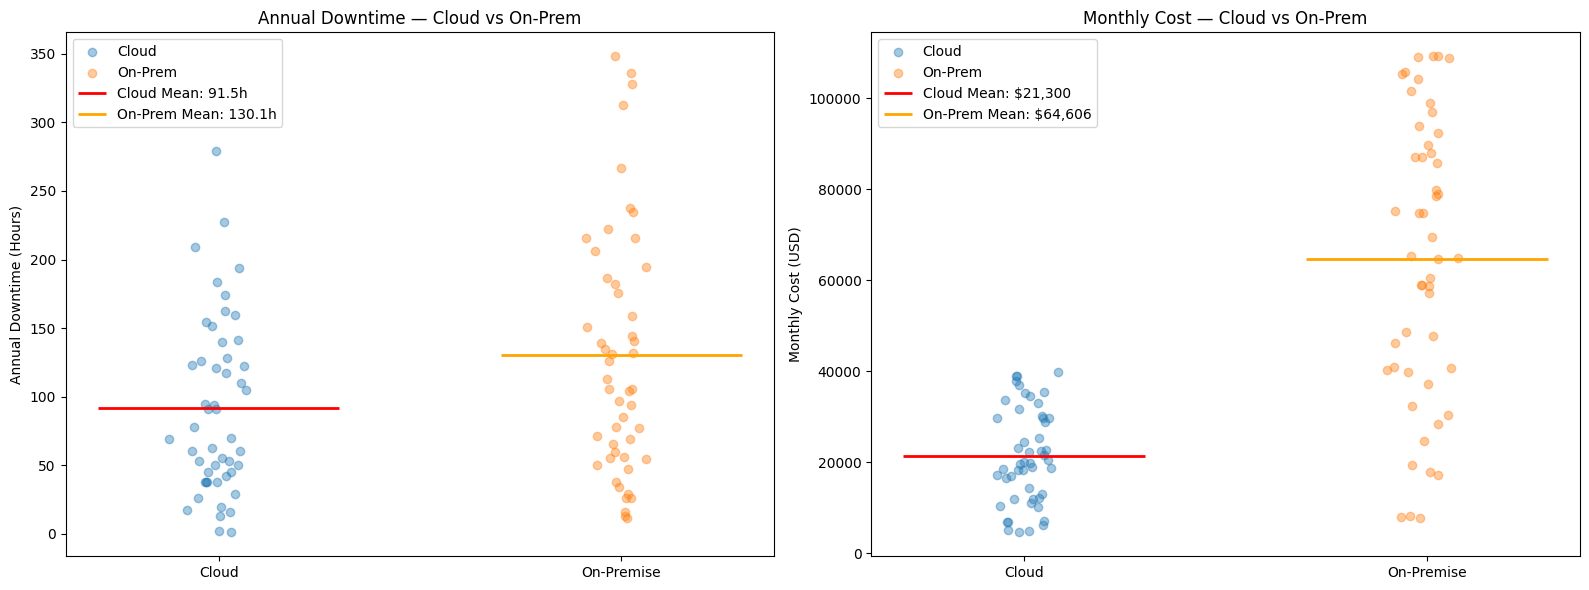

SUMMARY STATISTICS: CLOUD vs ON-PREMISE COMPARISON

ANNUAL DOWNTIME HOURS:
----------------------------------------
Cloud Infrastructure:
  Mean:     91.45 hours
  Median:   73.93 hours
  Std Dev:  63.63 hours
  Min:      1.12 hours
  Max:      279.00 hours

On-Premise Infrastructure:
  Mean:     130.08 hours
  Median:   109.19 hours
  Std Dev:  89.79 hours
  Min:      11.85 hours
  Max:      348.17 hours

Difference: On-Prem has 38.6 more hours downtime annually

MONTHLY COST (USD):
----------------------------------------
Cloud Infrastructure:
  Mean:     $21,300.45
  Median:   $19,939.23
  Std Dev:  $10,439.28
  Min:      $4,519.92
  Max:      $39,926.44

On-Premise Infrastructure:
  Mean:     $64,606.11
  Median:   $65,159.05
  Std Dev:  $31,023.64
  Min:      $7,687.59
  Max:      $109,315.38

Difference: On-Prem costs $43,305.66 more per month

ANNUAL COST COMPARISON:
  Cloud Annual Cost:     $255,605.37
  On-Premise Annual Cost: $775,273.27
  Annual Savings (Cloud): $519,667.90


In [19]:
df_exp1 = df_companies.copy()
df_exp1["is_cloud"] = df_exp1["infrastructure_type"] == "cloud"

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Downtime
cloud_down = df_exp1[df_exp1["infrastructure_type"]=="cloud"]["annual_downtime_hours"]
onprem_down = df_exp1[df_exp1["infrastructure_type"]=="on_prem"]["annual_downtime_hours"]

ax[0].scatter(np.random.normal(1, 0.04, len(cloud_down)), cloud_down, alpha=0.4, label="Cloud")
ax[0].scatter(np.random.normal(2, 0.04, len(onprem_down)), onprem_down, alpha=0.4, label="On-Prem")
ax[0].hlines([cloud_down.mean()], 0.7, 1.3, colors='red', linewidth=2, label=f'Cloud Mean: {cloud_down.mean():.1f}h')
ax[0].hlines([onprem_down.mean()], 1.7, 2.3, colors='orange', linewidth=2, label=f'On-Prem Mean: {onprem_down.mean():.1f}h')
ax[0].set_xticks([1, 2])
ax[0].set_xticklabels(["Cloud", "On-Premise"])
ax[0].set_ylabel("Annual Downtime (Hours)")
ax[0].set_title("Annual Downtime — Cloud vs On-Prem")
ax[0].legend()

# Cost
cloud_cost = df_exp1[df_exp1["infrastructure_type"]=="cloud"]["monthly_cost_usd"]
onprem_cost = df_exp1[df_exp1["infrastructure_type"]=="on_prem"]["monthly_cost_usd"]

ax[1].scatter(np.random.normal(1, 0.04, len(cloud_cost)), cloud_cost, alpha=0.4, label="Cloud")
ax[1].scatter(np.random.normal(2, 0.04, len(onprem_cost)), onprem_cost, alpha=0.4, label="On-Prem")
ax[1].hlines([cloud_cost.mean()], 0.7, 1.3, colors='red', linewidth=2, label=f'Cloud Mean: ${cloud_cost.mean():,.0f}')
ax[1].hlines([onprem_cost.mean()], 1.7, 2.3, colors='orange', linewidth=2, label=f'On-Prem Mean: ${onprem_cost.mean():,.0f}')
ax[1].set_xticks([1, 2])
ax[1].set_xticklabels(["Cloud", "On-Premise"])
ax[1].set_ylabel("Monthly Cost (USD)")
ax[1].set_title("Monthly Cost — Cloud vs On-Prem")
ax[1].legend()

plt.tight_layout()
plt.show()

# -----------------------------------
# Summary Statistics for Both Metrics
# -----------------------------------
print("=" * 60)
print("SUMMARY STATISTICS: CLOUD vs ON-PREMISE COMPARISON")
print("=" * 60)

# Annual Downtime Statistics
print("\nANNUAL DOWNTIME HOURS:")
print("-" * 40)
print("Cloud Infrastructure:")
print(f"  Mean:     {cloud_down.mean():.2f} hours")
print(f"  Median:   {cloud_down.median():.2f} hours")
print(f"  Std Dev:  {cloud_down.std():.2f} hours")
print(f"  Min:      {cloud_down.min():.2f} hours")
print(f"  Max:      {cloud_down.max():.2f} hours")

print("\nOn-Premise Infrastructure:")
print(f"  Mean:     {onprem_down.mean():.2f} hours")
print(f"  Median:   {onprem_down.median():.2f} hours")
print(f"  Std Dev:  {onprem_down.std():.2f} hours")
print(f"  Min:      {onprem_down.min():.2f} hours")
print(f"  Max:      {onprem_down.max():.2f} hours")

print(f"\nDifference: On-Prem has {onprem_down.mean() - cloud_down.mean():.1f} more hours downtime annually")

# Monthly Cost Statistics
print("\nMONTHLY COST (USD):")
print("-" * 40)
print("Cloud Infrastructure:")
print(f"  Mean:     ${cloud_cost.mean():,.2f}")
print(f"  Median:   ${cloud_cost.median():,.2f}")
print(f"  Std Dev:  ${cloud_cost.std():,.2f}")
print(f"  Min:      ${cloud_cost.min():,.2f}")
print(f"  Max:      ${cloud_cost.max():,.2f}")

print("\nOn-Premise Infrastructure:")
print(f"  Mean:     ${onprem_cost.mean():,.2f}")
print(f"  Median:   ${onprem_cost.median():,.2f}")
print(f"  Std Dev:  ${onprem_cost.std():,.2f}")
print(f"  Min:      ${onprem_cost.min():,.2f}")
print(f"  Max:      ${onprem_cost.max():,.2f}")

print(f"\nDifference: On-Prem costs ${onprem_cost.mean() - cloud_cost.mean():,.2f} more per month")

# Annual Cost Comparison
cloud_annual_cost = cloud_cost.mean() * 12
onprem_annual_cost = onprem_cost.mean() * 12
print(f"\nANNUAL COST COMPARISON:")
print(f"  Cloud Annual Cost:     ${cloud_annual_cost:,.2f}")
print(f"  On-Premise Annual Cost: ${onprem_annual_cost:,.2f}")
print(f"  Annual Savings (Cloud): ${onprem_annual_cost - cloud_annual_cost:,.2f}")

# Variability Analysis
print(f"\nVARIABILITY ANALYSIS:")
print(f"  Downtime CV - Cloud:    {(cloud_down.std()/cloud_down.mean()):.3f}")
print(f"  Downtime CV - On-Prem:  {(onprem_down.std()/onprem_down.mean()):.3f}")
print(f"  Cost CV - Cloud:        {(cloud_cost.std()/cloud_cost.mean()):.3f}")
print(f"  Cost CV - On-Prem:      {(onprem_cost.std()/onprem_cost.mean()):.3f}")

print("\n" + "=" * 60)


## -----------------------------------------------------------------------------------------
#### Experiment 2

Question: What are the single biggest drivers of cost and downtime (e.g., recovery time, security) in an IT infrastructure?
## --------------------------------------------------------------------------------------------
**Hypothesis:** Recovery Time (Mean Time to Recovery), system failure frequency, and security incidents are expected to be the primary drivers of annual downtime, with longer recovery times causing the greatest increases in total downtime. Monthly cost is expected to rise with higher scalability, performance, and security incident rates.

**Analysis Method:** To identify the single biggest drivers of downtime and cost, we used the same 100-company synthetic dataset from Experiment 1 and applied a correlation analysis.

For Experiment 2, we:

Selected key operational and business variables:

Annual Downtime (Hours)

Monthly Cost (USD)

Recovery Time (MTTR)

System Failures per Year

Security Incidents per Year

Performance Score

Scalability Score

Computed a correlation matrix to measure pairwise statistical relationships between variables.

Visualized these relationships using a correlation heatmap, which highlights the strength and direction (positive/negative) of each relationship.

Ranked the strongest predictors of:

Total annual downtime

Monthly operational cost

Correlation was chosen because it is the most appropriate method to quantify linear relationships between multiple continuous variables simultaneously.


**Results/Answer:** The correlation heatmap shows that Mean Time to Recovery (MTTR) is the strongest driver of annual downtime (r ≈ 0.74), showing that slower recovery leads to significantly higher downtime. System Failures per Year is a secondary driver (r ≈ 0.56), while security incidents have minimal impact on downtime. For cost, Scalability Score is the strongest factor (r ≈ –0.66), indicating that less scalable systems are more expensive. Security incidents (r ≈ 0.41) increase costs, while higher performance slightly reduces them (r ≈ –0.34). Overall, downtime is primarily driven by recovery speed, while cost is driven by scalability and security.


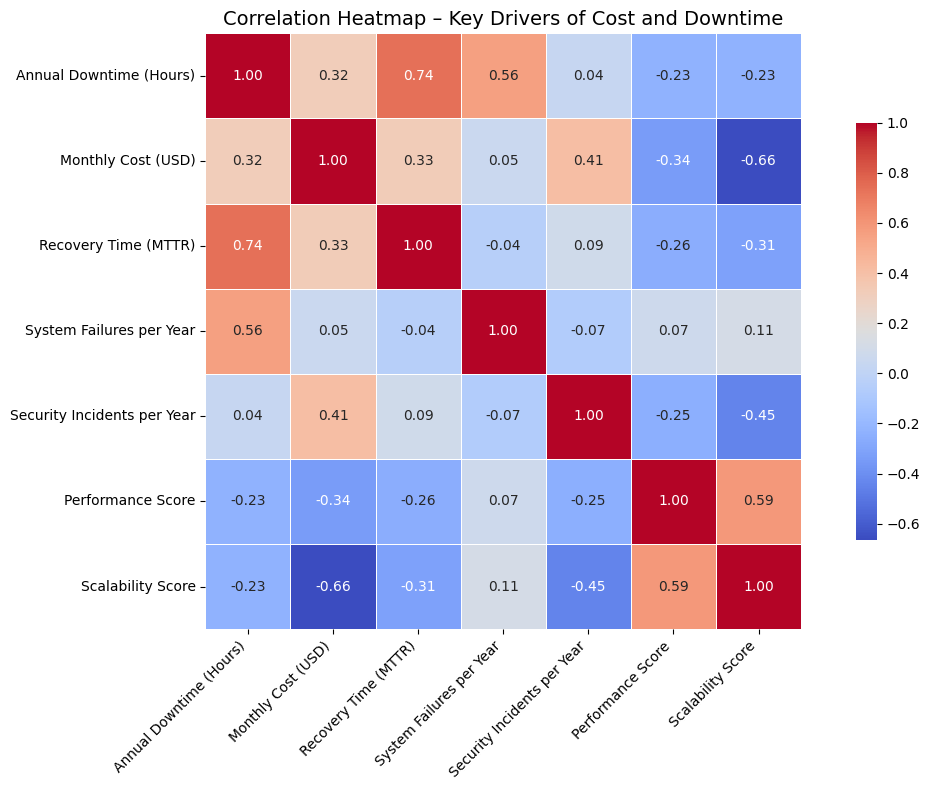


=== Correlation with Annual Downtime (Hours) ===
Recovery Time (MTTR)           0.737517
System Failures per Year       0.556604
Monthly Cost (USD)             0.323212
Performance Score             -0.234060
Scalability Score             -0.230505
Security Incidents per Year    0.037119
Name: Annual Downtime (Hours), dtype: float64

=== Correlation with Monthly Cost (USD) ===
Scalability Score             -0.663891
Security Incidents per Year    0.411668
Performance Score             -0.340530
Recovery Time (MTTR)           0.325887
Annual Downtime (Hours)        0.323212
System Failures per Year       0.051521
Name: Monthly Cost (USD), dtype: float64


In [20]:
# ---------------------------------------------
# EXPERIMENT 2: Key Drivers of Cost & Downtime
# ---------------------------------------------
# Question:
# What are the single biggest drivers of cost and downtime
# (e.g., recovery time, security) in an IT infrastructure?


# 1. Select priority variables (drivers + outcomes)
priority_cols = [
    "annual_downtime_hours",        # outcome: downtime
    "monthly_cost_usd",             # outcome: cost
    "mttr_hours",                   # driver: recovery time
    "incident_frequency_per_year",  # driver: how often things break
    "security_incidents_per_year",  # driver: security issues
    "performance_index",            # driver: overall performance
    "scalability_score"             # driver: ability to scale
]

df_exp2 = df_companies[priority_cols].copy()

# 2. Renaming columns to ensure better readability for the diagram
df_exp2 = df_exp2.rename(columns={
    "annual_downtime_hours": "Annual Downtime (Hours)",
    "monthly_cost_usd": "Monthly Cost (USD)",
    "mttr_hours": "Recovery Time (MTTR)",
    "incident_frequency_per_year": "System Failures per Year",
    "security_incidents_per_year": "Security Incidents per Year",
    "performance_index": "Performance Score",
    "scalability_score": "Scalability Score"
})

# 3. Compute correlation matrix
corr_matrix = df_exp2.corr()

# 4. Plot correlation heatmap
plt.figure(figsize=(12, 8))
sn.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.7}
)
plt.title("Correlation Heatmap – Key Drivers of Cost and Downtime", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Print strongest drivers for each main outcome
targets = ["Annual Downtime (Hours)", "Monthly Cost (USD)"]

for target in targets:
    # sort by absolute correlation strength (ignore self-correlation)
    target_corr = (
        corr_matrix[target]
        .drop(target)
        .dropna()
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    print(f"\n=== Correlation with {target} ===")
    print(target_corr)


## ---------------------------------------------------------------------------------------
#### Experiment 3
Question: What is the true financial impact of a catastrophic failure: a major public cloud versus a critical on-premise outage?
## ---------------------------------------------------------------------------------------

**Hypothesis:** A cloud outage will produce an extremely large system-wide financial impact because it simultaneously affects many companies depending on a shared provider. In contrast, an on-premise catastrophic failure will generate a severe but localized loss, affecting only a single organization at a time. Therefore, cloud failures create ecosystem-scale risk, whereas on-prem failures create isolated individual risk.


**Analysis Method:** We expanded the catastrophic-failure model to include:
Entity-level financial exposure for 100 companies
Cloud providers (AWS, Azure, GCP, Cloudflare) and individual enterprise companies
Outage-duration-dependent revenue loss
Revenue-at-risk and loss aggregation across providers
Scenario modeling for a 12-hour cloud outage vs. a 24-hour on-prem outage
The dataset includes detailed measurements such as total loss, number of dependent companies, and per-hour revenue exposure.

**Results/Answer:**
Cloud Catastrophic Failure — System-Wide Impact

Across all outage segments and providers, cloud outages produce massive cumulative financial loss, sometimes exceeding hundreds of millions per provider group.

Key findings:
Cloudflare exhibited the highest aggregate impact:
Total Loss: $650,128,394 - 18 companies

Azure had the second-highest systemic exposure:
$303,993,308 - 7 companies

GCP and AWS also showed substantial ecosystem loss:

GCP: $283,196,766

AWS: $162,550,020

This confirms cloud outages cause broad, systemic economic impact, even if each individual company suffers only a fraction of the total.


On-Premise Catastrophic Failure  Individual Impact

On-premise failures affect only one company at a time, yet the losses per company can be enormous.

Top on-premise losses (24-hour individual outage):
- Johnson & Johnson: \$174,963,471
- Epic Games: \$142,839,180
- L’Oréal Groupe: \$93,192,017
- Snapchat: \$92,977,838
- Dropbox: \$91,596,280

These individual losses routinely exceed the impact of a cloud outage on any single company.

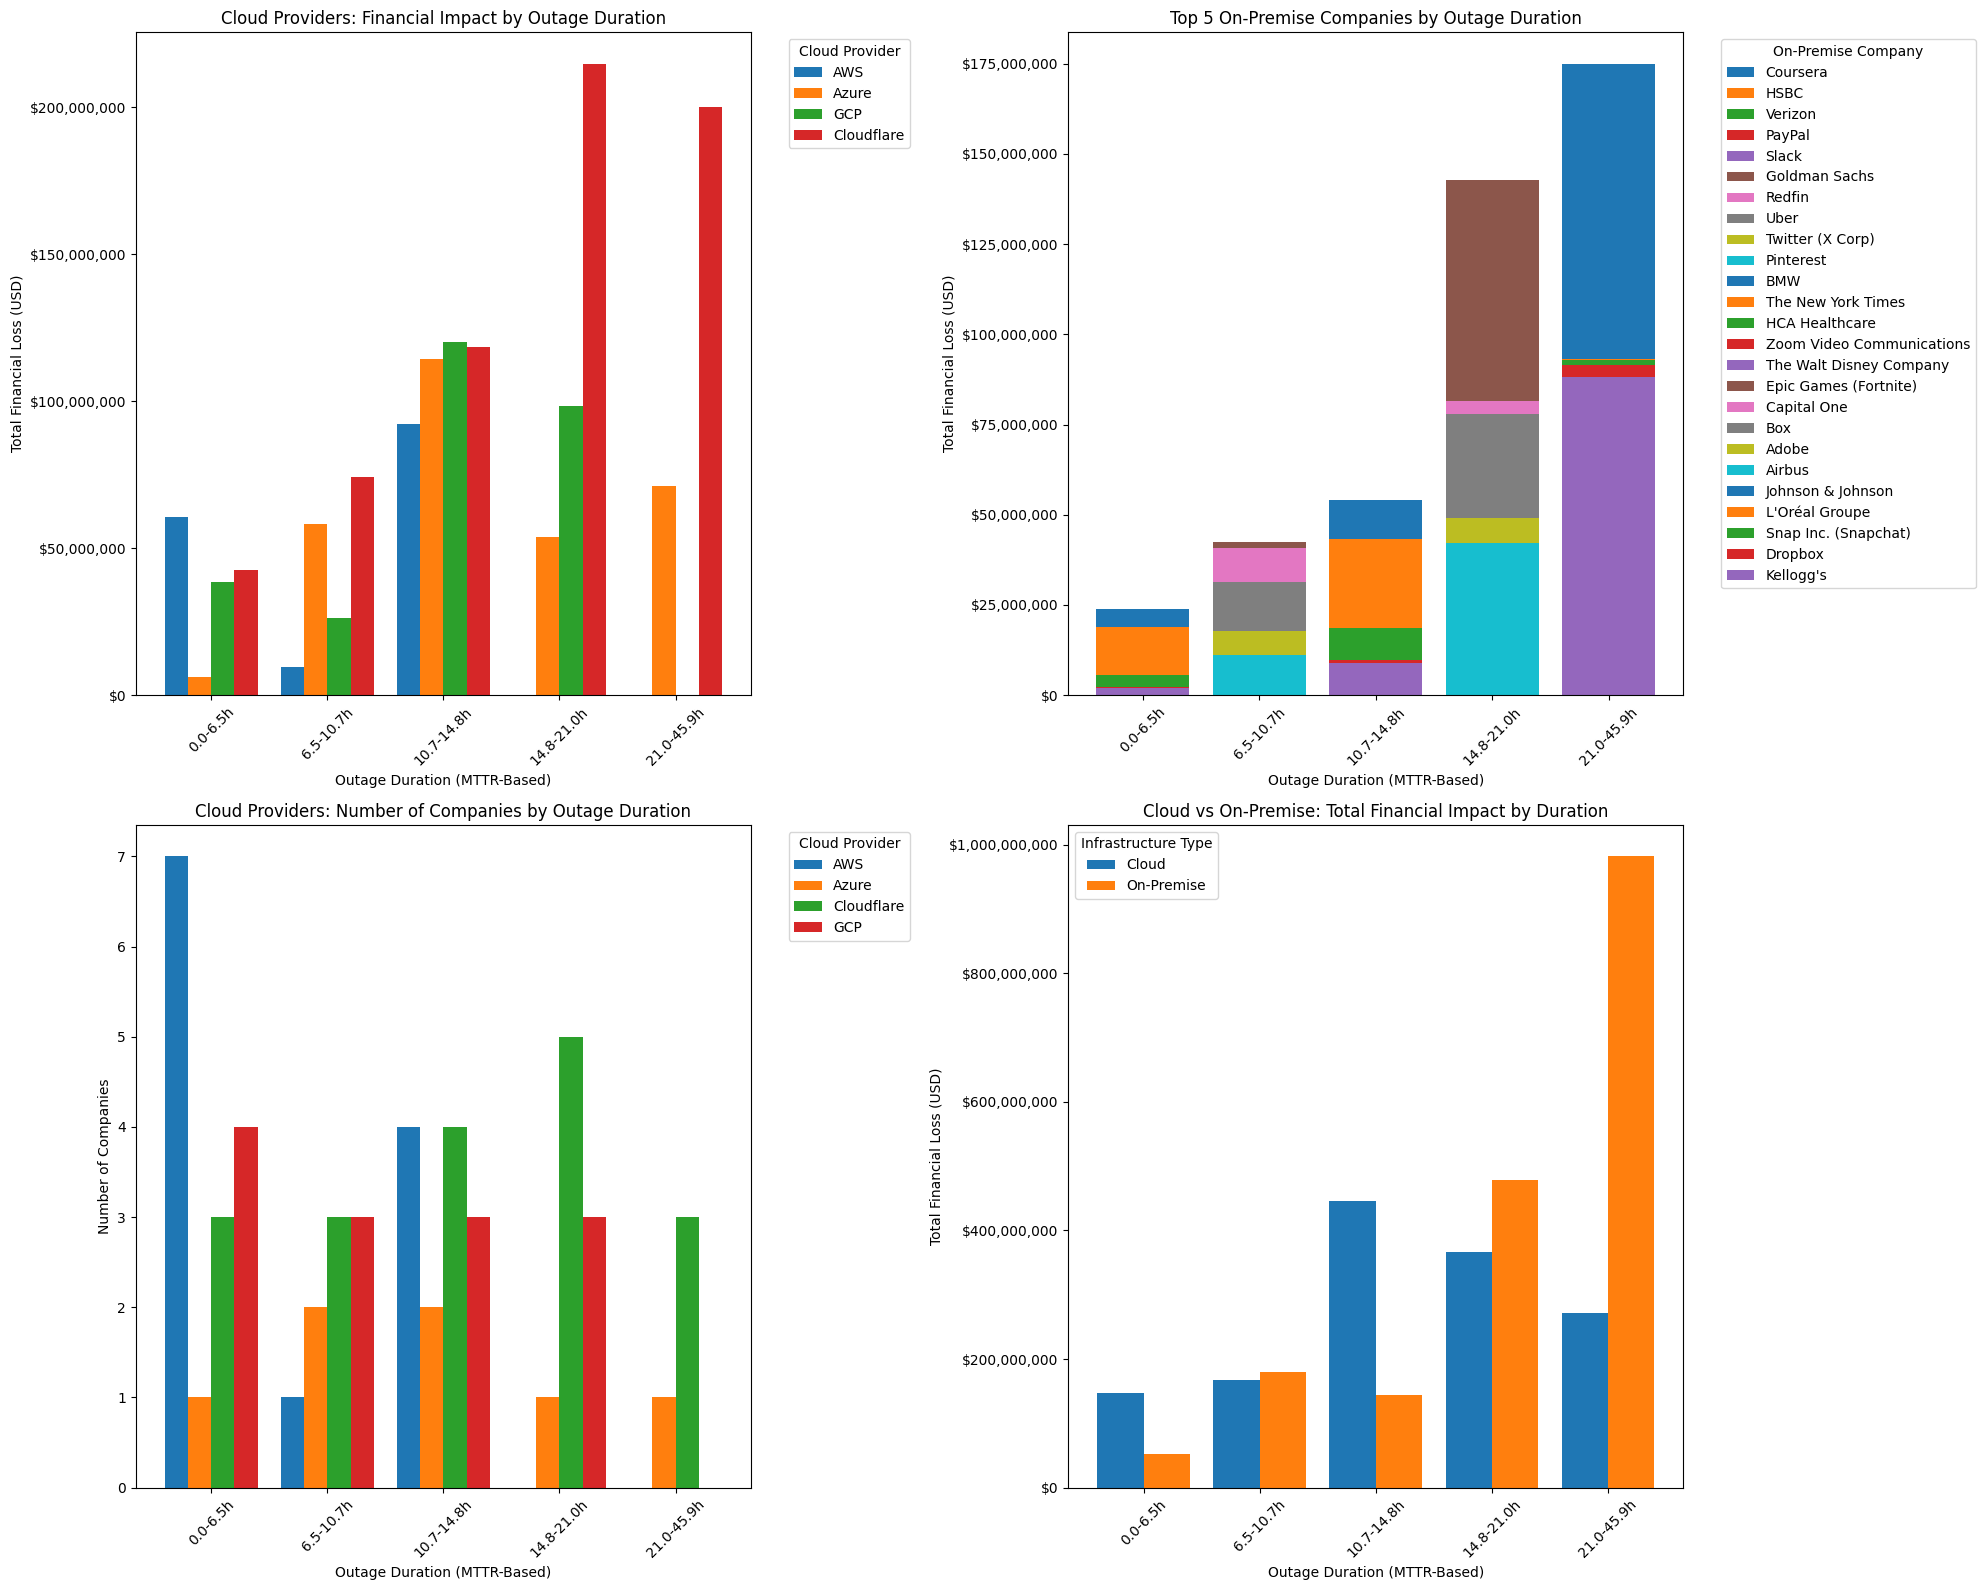


CATASTROPHIC FAILURE FINANCIAL IMPACT ANALYSIS

Total Companies Analyzed: 100
Cloud Companies: 50
On-Premise Companies: 50

FINANCIAL IMPACT BY ENTITY AND OUTAGE DURATION:
--------------------------------------------------------------------------------

0.0-6.5h Outage Duration:
  Provider AWS                       | Companies: 7 | Total Loss: $     60,693,392 | Revenue@Risk: $ 15,067,158,995
  Provider Cloudflare                | Companies: 3 | Total Loss: $     42,491,620 | Revenue@Risk: $  9,751,073,330
  Provider GCP                       | Companies: 4 | Total Loss: $     38,450,959 | Revenue@Risk: $ 11,009,585,558
  Company Coursera                  | Companies: 1 | Total Loss: $     23,875,669 | Revenue@Risk: $  2,692,120,762
  Company HSBC                      | Companies: 1 | Total Loss: $     18,964,468 | Revenue@Risk: $  4,819,516,563
  Provider Azure                     | Companies: 1 | Total Loss: $      6,284,830 | Revenue@Risk: $  2,082,265,964
  Company Verizon        

In [21]:
# --------------------------------------------------------
# Experiment 3 — Enhanced Catastrophic Failure Impact Analysis
# --------------------------------------------------------

df_exp3 = df_companies.copy()



# ----------------------------
# 1. Create Dynamic MTTR-Based Time Buckets
# ----------------------------

mttr_percentiles = df_exp3["mttr_hours"].quantile([0.2, 0.4, 0.6, 0.8, 1.0]).values
bins = [0] + mttr_percentiles.tolist()

labels = []
for i in range(len(bins)-1):
    labels.append(f"{bins[i]:.1f}-{bins[i+1]:.1f}h")

df_exp3["mttr_bucket"] = pd.cut(df_exp3["mttr_hours"], bins=bins, labels=labels, include_lowest=True)
df_exp3["mttr_bucket"] = pd.Categorical(df_exp3["mttr_bucket"], categories=labels, ordered=True)

# Calculate Financial Impact by Provider and Time Bucket
impact_analysis = []

for bucket in df_exp3["mttr_bucket"].unique():
    if pd.isna(bucket):
        continue

    bucket_companies = df_exp3[df_exp3["mttr_bucket"] == bucket]

    # Cloud providers
    for provider in ["AWS", "Azure", "GCP", "Cloudflare"]:
        provider_companies = bucket_companies[
            (bucket_companies["infrastructure_type"] == "cloud") &
            (bucket_companies["provider"] == provider)
        ]
        if len(provider_companies) > 0:
            total_loss = provider_companies["annual_downtime_business_loss_usd"].sum()
            avg_loss = provider_companies["annual_downtime_business_loss_usd"].mean()

            impact_analysis.append({
                "bucket": bucket,
                "provider_type": "Cloud",
                "provider": provider,
                "entity_name": provider,
                "company_count": len(provider_companies),
                "total_financial_impact": total_loss,
                "avg_impact_per_company": avg_loss,
                "total_revenue_at_risk": provider_companies["annual_revenue_usd"].sum()
            })

    # On-premise companies (individual)
    onprem_companies = bucket_companies[bucket_companies["infrastructure_type"] == "on_prem"]
    for _, company in onprem_companies.iterrows():
        impact_analysis.append({
            "bucket": bucket,
            "provider_type": "On-Premise",
            "provider": "On-Premise",
            "entity_name": company["company_name"],
            "company_count": 1,
            "total_financial_impact": company["annual_downtime_business_loss_usd"],
            "avg_impact_per_company": company["annual_downtime_business_loss_usd"],
            "total_revenue_at_risk": company["annual_revenue_usd"]
        })

impact_df = pd.DataFrame(impact_analysis)

# Pivot tables
pivot_total = impact_df.pivot_table(
    index="bucket",
    columns="entity_name",
    values="total_financial_impact",
    fill_value=0
)

pivot_count_cloud = impact_df[impact_df["provider_type"] == "Cloud"].pivot_table(
    index="bucket",
    columns="entity_name",
    values="company_count",
    fill_value=0
)

cloud_vs_onprem = impact_df.groupby(["bucket", "provider_type"])["total_financial_impact"].sum().unstack(fill_value=0)

cloud_entities = ["AWS", "Azure", "GCP", "Cloudflare"]
onprem_entities = [name for name in pivot_total.columns if name not in cloud_entities]

bucket_order = labels

pivot_total_ordered = pivot_total.reindex(bucket_order)
pivot_count_cloud_ordered = pivot_count_cloud.reindex(bucket_order)
cloud_vs_onprem_ordered = cloud_vs_onprem.reindex(bucket_order)

# --------------------------------------------------------
# 2. Visualizations
# --------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

def apply_dollar_format(axis):
    axis.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# 1. Cloud Providers Financial Impact
pivot_total_ordered[cloud_entities].plot(kind="bar", width=0.8, ax=axes[0, 0])
axes[0, 0].set_title("Cloud Providers: Financial Impact by Outage Duration")
axes[0, 0].set_ylabel("Total Financial Loss (USD)")
axes[0, 0].set_xlabel("Outage Duration (MTTR-Based)")
axes[0, 0].legend(title="Cloud Provider", bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].tick_params(axis='x', rotation=45)
apply_dollar_format(axes[0, 0])

# 2. On-Premise Top 5 per bucket
for bucket in bucket_order:
    bucket_data = pivot_total_ordered.loc[bucket, onprem_entities]
    top_companies = bucket_data.sort_values(ascending=False).head(5)
    for company, value in top_companies.items():
        axes[0, 1].bar(bucket, value, label=company)
axes[0, 1].set_title("Top 5 On-Premise Companies by Outage Duration")
axes[0, 1].set_ylabel("Total Financial Loss (USD)")
axes[0, 1].set_xlabel("Outage Duration (MTTR-Based)")
axes[0, 1].legend(title="On-Premise Company", bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].tick_params(axis='x', rotation=45)
apply_dollar_format(axes[0, 1])

# 3. Cloud Company Count Distribution
pivot_count_cloud_ordered.plot(kind="bar", width=0.8, ax=axes[1, 0])
axes[1, 0].set_title("Cloud Providers: Number of Companies by Outage Duration")
axes[1, 0].set_ylabel("Number of Companies")
axes[1, 0].set_xlabel("Outage Duration (MTTR-Based)")
axes[1, 0].legend(title="Cloud Provider", bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Cloud vs On-Premise Aggregated Loss
cloud_vs_onprem_ordered.plot(kind="bar", width=0.8, ax=axes[1, 1])
axes[1, 1].set_title("Cloud vs On-Premise: Total Financial Impact by Duration")
axes[1, 1].set_ylabel("Total Financial Loss (USD)")
axes[1, 1].set_xlabel("Outage Duration (MTTR-Based)")
axes[1, 1].legend(title="Infrastructure Type")
axes[1, 1].tick_params(axis='x', rotation=45)
apply_dollar_format(axes[1, 1])

plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 4. Summary Statistics
# --------------------------------------------------------

print("\n" + "="*80)
print("CATASTROPHIC FAILURE FINANCIAL IMPACT ANALYSIS")
print("="*80)

print(f"\nTotal Companies Analyzed: {len(df_exp3)}")
print(f"Cloud Companies: {len(df_exp3[df_exp3['infrastructure_type'] == 'cloud'])}")
print(f"On-Premise Companies: {len(df_exp3[df_exp3['infrastructure_type'] == 'on_prem'])}")

print("\nFINANCIAL IMPACT BY ENTITY AND OUTAGE DURATION:")
print("-"*80)

for bucket in bucket_order:
    bucket_data = impact_df[impact_df["bucket"] == bucket]
    print(f"\n{bucket} Outage Duration:")
    bucket_data_sorted = bucket_data.sort_values("total_financial_impact", ascending=False)

    for _, row in bucket_data_sorted.iterrows():
        entity_type = "Provider" if row["provider_type"] == "Cloud" else "Company"
        print(f"  {entity_type} {row['entity_name']:25} | Companies: {row['company_count']:.0f} | "
              f"Total Loss: ${row['total_financial_impact']:>15,.0f} | "
              f"Revenue@Risk: ${row['total_revenue_at_risk']:>15,.0f}")

# --------------------------------------------------------
# 5. Entity-Level Risk
# --------------------------------------------------------

print("\n" + "="*80)
print("ENTITY-LEVEL RISK ANALYSIS")
print("="*80)

print("\nCLOUD PROVIDER RISK (Aggregated Impact):")
cloud_summary = impact_df[impact_df["provider_type"] == "Cloud"].groupby("entity_name").agg({
    "company_count": "sum",
    "total_financial_impact": "sum",
    "total_revenue_at_risk": "sum"
}).round(0)

cloud_summary["risk_ratio"] = (cloud_summary["total_financial_impact"] /
                               cloud_summary["total_revenue_at_risk"] * 100).round(2)

for provider, row in cloud_summary.iterrows():
    print(f"  {provider:12} | Companies: {row['company_count']:>2.0f} | "
          f"Total Loss: ${row['total_financial_impact']:>15,.0f} | "
          f"Risk Ratio: {row['risk_ratio']:5.2f}%")

print("\nTOP 10 ON-PREMISE COMPANY RISK:")
onprem_summary = impact_df[impact_df["provider_type"] == "On-Premise"].groupby("entity_name").agg({
    "total_financial_impact": "sum",
    "total_revenue_at_risk": "sum"
}).round(0)
onprem_summary["risk_ratio"] = (onprem_summary["total_financial_impact"] /
                                onprem_summary["total_revenue_at_risk"] * 100).round(2)

top_onprem = onprem_summary.nlargest(10, "total_financial_impact")
for company, row in top_onprem.iterrows():
    print(f"  {company:30} | Total Loss: ${row['total_financial_impact']:>12,.0f} | "
          f"Risk Ratio: {row['risk_ratio']:5.2f}%")

# --------------------------------------------------------
# 6. Scenario Modeling
# --------------------------------------------------------

print("\n" + "="*80)
print("SCENARIO MODELING: CATASTROPHIC OUTAGE IMPACT")
print("="*80)

print("\nSCENARIO: Major Cloud Provider Outage (12-hour duration)")
cloud_companies = df_exp3[df_exp3["infrastructure_type"] == "cloud"]
scenario_impact = {}

for provider in ["AWS", "Azure", "GCP", "Cloudflare"]:
    provider_companies = cloud_companies[cloud_companies["provider"] == provider]
    if len(provider_companies) > 0:
        outage_hours = 12
        hourly_loss = provider_companies["revenue_loss_per_hour_usd"].sum()
        total_impact = outage_hours * hourly_loss
        scenario_impact[provider] = {
            "companies_affected": len(provider_companies),
            "total_impact": total_impact,
            "hourly_loss_rate": hourly_loss
        }

for provider, impact in scenario_impact.items():
    print(f"{provider:12}: {impact['companies_affected']:2d} companies, "
          f"${impact['total_impact']:>15,.0f} total loss, "
          f"${impact['hourly_loss_rate']:>12,.0f}/hour")

print(f"\nTOTAL CLOUD ECOSYSTEM RISK (12h outage): ${sum(s['total_impact'] for s in scenario_impact.values()):,.0f}")

print("\nSCENARIO: Individual On-Premise Infrastructure Failures (24-hour outage)")
onprem_companies = df_exp3[df_exp3["infrastructure_type"] == "on_prem"]
worst_case_onprem = onprem_companies.nlargest(10, "revenue_loss_per_hour_usd")

for _, company in worst_case_onprem.iterrows():
    impact_24h = 24 * company["revenue_loss_per_hour_usd"]
    print(f"{company['company_name']:30}: ${impact_24h:>12,.0f}")
